# D5 · The battery: an equivalent circuit, and why voltage sag sizes the pack

The battery is the most counter-intuitive part of the design. It holds 70 kWh, and the mission uses about half of
it, yet it is not oversized: it is *exactly* as big as one 60-second failure case needs, and the reason is voltage,
not energy.

**What you will learn**
1. The cell model: open-circuit voltage (OCV) and two RC branches, fitted to published Samsung INR21700-50G data.
2. Pack scaling: 210 cells in series, a continuous number of parallel strings (a design variable), a power-density
   factor, end-of-life ageing.
3. How a battery with resistance becomes an *equation* in the optimizer, and the one inequality that picks the
   physical root.
4. The engine-out hover: reproducing the pack size from the sag alone, to the decimal.

**Run time:** under a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft
from aircraft_closure.powertrain import cells
from aircraft_closure.powertrain.components.battery_ecm import inr21700_50g_cell

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
pack = aircraft.powertrain.topology.instances["battery"].component          # the sized pack (numbers)
cell = inr21700_50g_cell()

## 1. The cell: OCV plus two RC branches

The cell is the Samsung INR21700-50G (4.9 Ah, 69 g, 3.6 V nominal, 2.5-4.2 V), with data from Paudel et al.,
*Batteries* 2025, 11, 313 (CC BY 4.0), digitized into `data/batteries/`. Its equivalent circuit is

```
   OCV(SOC) ──R0──┬──R1──┬──┬──R2──┬── terminal
                  └──C1──┘  └──C2──┘          τ1 = R1 C1 = 8 s,  τ2 = R2 C2 = 43 s
```

- **OCV(SOC):** a degree-7 polynomial fitted to 21 points of the 30 °C curve (rms 9 mV). A polynomial, not a
  spline: IPOPT needs it smooth and cheap (a B-spline elsewhere stalled the solver).
- **Resistances:** one global least-squares fit to all 308 discharge pulse-resistance points (2-180 s pulses, SOC
  0.2-0.8, −10 to 45 °C), as an `asb.Opti` problem. Resistance rises steeply at low SOC.

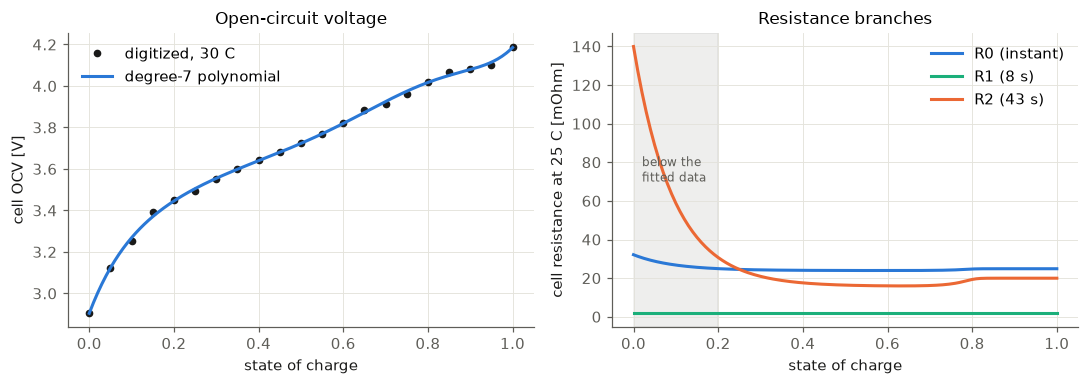

PASS  OCV polynomial within 10 mV rms of the data


In [2]:
ocv_table = cells.load_ocv_table()
soc_data, ocv_data = ocv_table.at_temperature(30.0)
soc = np.linspace(0, 1, 201)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(soc_data, ocv_data, "o", color=ink, ms=4, label="digitized, 30 C")
axes[0].plot(soc, cell.ocv_model.voltage_V(soc), color=blue, lw=2, label="degree-7 polynomial")
axes[0].set(xlabel="state of charge", ylabel="cell OCV [V]", title="Open-circuit voltage"); axes[0].legend()
r0, r1, r2 = zip(*[cell.resistance_model.resistances_ohm(s, 25.0) for s in soc])
for values, label, color in ((r0, "R0 (instant)", blue), (r1, "R1 (8 s)", aqua), (r2, "R2 (43 s)", orange)):
    axes[1].plot(soc, 1e3 * np.array(values, dtype=float), color=color, lw=2, label=label)
axes[1].axvspan(0, 0.2, color=ink_muted, alpha=0.1); axes[1].text(0.02, 70, "below the\nfitted data", fontsize=8, color=ink_muted)
axes[1].set(xlabel="state of charge", ylabel="cell resistance at 25 C [mOhm]", title="Resistance branches")
axes[1].legend(); plt.tight_layout(); plt.show()
fit_rms = np.sqrt(np.mean((cell.ocv_model.voltage_V(soc_data) - ocv_data)**2))
check("OCV polynomial within 10 mV rms of the data", fit_rms < 0.010)

R2 at SOC 0.1 is several times its mid-SOC value. The fit holds R constant-shaped above SOC 0.8 and lets it keep
rising below 0.2 (outside the data): conservative, and deliberately so, because the failure hovers end at SOC 0.10.

## 2. From cell to pack

`EquivalentCircuitBattery` scales the cell:

| Pack quantity | Expression | Halo |
|---|---|---|
| series cells N_s | assumption | 210 (756 V nominal, 525-882 V window) |
| parallel strings N_p | **design variable** (continuous) | solved |
| capacity | N_p × 4.9 Ah × 0.8 (end of life) | |
| resistance | R_cell × N_s / N_p × 1.5 (end of life) / F | F = 5 |
| current rating | N_p × 9.8 A × F | |
| mass | N_s N_p × 69 g / 0.7 (cells are 70 % of pack mass) | |

**F, the power-density factor**, is an explicit, labelled assumption (author decision, plan 021): the 50G's
*shape* (OCV curve, resistance trends) is kept, but resistance is divided by 5 and current rating multiplied by 5,
standing for a more power-dense cell of the same chemistry, with no mass penalty. Below F ≈ 5 the current rating
sizes the pack; above F ≈ 8 reserve energy does.

In [3]:
limits = pack.get_limits()
print(f"N_s {pack.count_series}, N_p {pack.count_parallel:.2f} -> {pack.count_cells:,.0f} cells, "
      f"mass {pack.get_mass():.0f} kg, energy {pack.energy_capacity_J / 3.6e6:.1f} kWh (end of life)")
print(f"current rating {limits.max_discharge_current_A:,.0f} A, power rating {pack.power_max_discharge_W / 1e3:.0f} kW, "
      f"voltage window {limits.min_voltage_V:.0f}-{limits.max_voltage_V:.0f} V")
print(f"pack specific energy {pack.energy_capacity_J / 3600 / pack.get_mass():.0f} Wh/kg at end of life")
check("pack energy is the documented 70 kWh", abs(pack.energy_capacity_J / 3.6e6 - 70.0) < 0.1)

N_s 210, N_p 22.95 -> 4,820 cells, mass 475 kg, energy 70.0 kWh (end of life)
current rating 1,125 A, power rating 850 kW, voltage window 525-882 V
pack specific energy 147 Wh/kg at end of life
PASS  pack energy is the documented 70 kWh


## 3. A battery as an equation

Over an interval of duration Δt at constant current I, starting from SOC s₀ and RC voltages v_k0, the model computes
(all closed form, `battery_ecm.py: evaluate`):

- SOC by coulomb counting, s₁ = s₀ − I Δt / Q; OCV and resistances evaluated at the **mid-interval** SOC (second-order
  accurate energy);
- each RC voltage **exactly** for constant current: v_k(Δt) = I R_k + (v_k0 − I R_k) e^(−Δt/τ_k);
- the **interval-mean** terminal voltage, which is *linear in I*:  V = V* − I R_eff, with V* = OCV − Σ v_k0 g_k and
  R_eff = R0 + Σ R_k (1 − g_k), g_k = (τ_k/Δt)(1 − e^(−Δt/τ_k)).

The flight point needs a power P from the pack, so it adds the current as a variable and the equality P = V I:

$$R_{eff} I^2 - V^* I + P = 0$$

That quadratic has **two roots**. The low-current one is the physical operating point; the high-current one is past
the matched-load point, dissipating more than it delivers. Instead of writing the closed-form root (which is NaN for
P > V*²/4R_eff and has an infinite derivative at the boundary), the code keeps the equality and adds one smooth
inequality:

$$V / V^* \ge 0.5 \;\Longleftrightarrow\; I \le V^*/2R_{eff} \quad(\text{low root, and } P \le P_{max} = V^{*2}/4R_{eff})$$

so an impossible power demand becomes an ordinary infeasibility. Watch it work:

In [4]:
def solve_current(power_W, current_start_A, soc_start=0.3, duration_s=20.0):
    opti = asb.Opti()
    current_A = opti.variable(init_guess=current_start_A, scale=100.0)
    state = pack.evaluate(current_A, soc_start, duration_s, None)
    opti.subject_to([state.power_electric_W / power_W == 1, state.voltage_V / state.voltage_driving_V >= 0.5])
    opti.minimize(0)
    try:
        solution = opti.solve(verbose=False)
        return f"I = {solution.value(current_A):7.1f} A, V = {solution.value(state.voltage_V):6.1f} V"
    except RuntimeError:
        return "no solution (IPOPT reports infeasibility)"

state = pack.evaluate(1000.0, 0.3, 20.0, None)
v_star, r_eff = float(state.voltage_driving_V), float(state.resistance_effective_ohm)
for power_W in (6e5,):
    disc = np.sqrt(v_star**2 - 4 * r_eff * power_W)
    print(f"600 kW from SOC 0.3: roots of the quadratic {(v_star - disc) / 2 / r_eff:.0f} A and {(v_star + disc) / 2 / r_eff:.0f} A")
print("start   100 A ->", solve_current(6e5, 100.0))
print("start 8,000 A ->", solve_current(6e5, 8000.0))
print(f"matched-load ceiling V*^2/4R = {v_star**2 / 4 / r_eff / 1e3:.0f} kW; asking for 2,500 kW ->", solve_current(2.5e6, 100.0))

600 kW from SOC 0.3: roots of the quadratic 988 A and 4503 A
start   100 A -> I =   988.1 A, V =  607.2 V
start 8,000 A -> no solution (IPOPT reports infeasibility)
matched-load ceiling V*^2/4R = 1016 kW; asking for 2,500 kW -> no solution (IPOPT reports infeasibility)


From a good start the solver lands on the low root; from a start near the high root the branch constraint makes it
fail rather than return the unphysical answer; and above the matched-load ceiling there is simply no solution. In the
sizing, the 0 A starting guess (with cooling on) keeps every point on the right branch.

## 4. What sizes the pack: the engine-out hover

The engine fails at the end of the take-off hover. The aircraft must hover **60 s at maximum weight on one
turbogenerator plus the battery**, starting at the 30 % reserve state of charge (with the RC branches already
polarized), and may go down to 10 %. At the end, the terminal voltage must still be at or above 210 × 2.5 V = 525 V.
The sizing splits that hover into three 20 s sub-intervals so the voltage can follow the falling SOC:

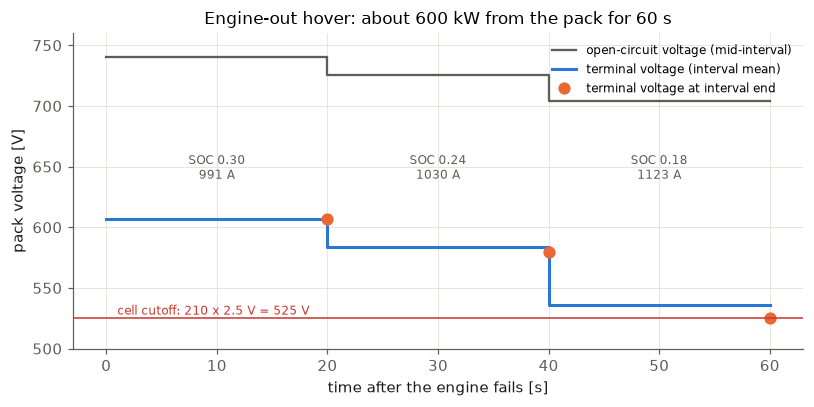

PASS  the end voltage of the engine-out hover sits on the 525 V cutoff


In [5]:
trace = ref.engine_out_trace
time_s = [0.0] + [row["time_start_s"] + row["duration_s"] for row in trace]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.step([row["time_start_s"] for row in trace] + [60], [row["voltage_ocv_V"] for row in trace] + [trace[-1]["voltage_ocv_V"]],
        where="post", color=ink_muted, lw=1.5, label="open-circuit voltage (mid-interval)")
ax.step([row["time_start_s"] for row in trace] + [60], [row["voltage_bus_V"] for row in trace] + [trace[-1]["voltage_bus_V"]],
        where="post", color=blue, lw=2, label="terminal voltage (interval mean)")
ax.plot([row["time_start_s"] + row["duration_s"] for row in trace], [row["voltage_end_V"] for row in trace], "o",
        color=orange, ms=7, label="terminal voltage at interval end")
ax.axhline(525, color=red, lw=1); ax.text(1, 528, "cell cutoff: 210 x 2.5 V = 525 V", color=red, fontsize=8)
for row in trace:
    ax.text(row["time_start_s"] + 10, 640, f"SOC {row['soc_start']:.2f}\n{row['current_A']:.0f} A", ha="center", fontsize=8, color=ink_muted)
ax.set(xlabel="time after the engine fails [s]", ylabel="pack voltage [V]", ylim=(500, 760),
       title="Engine-out hover: about 600 kW from the pack for 60 s")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()
check("the end voltage of the engine-out hover sits on the 525 V cutoff", abs(trace[-1]["voltage_end_V"] - 525) < 1e-3)

The sag grows as the SOC falls (lower OCV, higher resistance, more current for the same power). The pack ends
exactly on the cutoff. Adding parallel strings lowers the pack resistance (∝ 1/N_p), so the optimizer adds strings
until the sag fits, and no further.

**Reproduce the pack size from that one requirement.** Take only the three power demands of the engine-out hover from
the sized result, and ask: what is the smallest N_p whose end voltage is 525 V?

In [6]:
opti = asb.Opti()
count_parallel = opti.variable(init_guess=20.0, lower_bound=1.0)
candidate = replace(pack, count_parallel=count_parallel)
soc_now, rc_now = 0.30, None                                    # reserve SOC; polarization fully developed ("steady")
for row in trace:
    current_A = opti.variable(init_guess=900.0, scale=100.0)
    state = candidate.evaluate(current_A, soc_now, row["duration_s"], rc_now)
    opti.subject_to([state.power_electric_W / row["power_W"] == 1, state.voltage_V / state.voltage_driving_V >= 0.5])
    soc_now, rc_now = state.soc_next, state.voltage_rc_end_V
opti.subject_to(state.voltage_end_V >= 525.0)
opti.minimize(count_parallel)
solution = opti.solve(verbose=False)
print(f"smallest N_p for the engine-out sag: {solution.value(count_parallel):.4f}")
print(f"N_p in the sized aircraft          : {ref.design.count_parallel_battery:.4f}")
check("the engine-out voltage sag alone reproduces the pack size",
      abs(solution.value(count_parallel) - ref.design.count_parallel_battery) < 1e-3)

smallest N_p for the engine-out sag: 22.9527
N_p in the sized aircraft          : 22.9527
PASS  the engine-out voltage sag alone reproduces the pack size


The whole 70 kWh, 475 kg pack is set by 60 seconds of one failure case. Now compare with energy:

capacity 70.0 kWh
net mission use (SOC 0.95 -> 0.43): 36.1 kWh
engine-out hover (SOC 0.30 -> 0.106): 13.6 kWh in 60 s


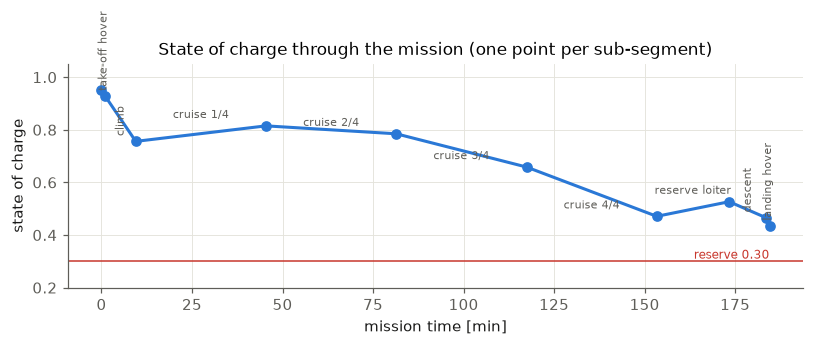

In [7]:
used_mission_kWh = (0.95 - ref.soc_end) * pack.energy_capacity_J / 3.6e6
used_engine_out_kWh = (0.30 - ref.soc_after_engine_out) * pack.energy_capacity_J / 3.6e6
print(f"capacity {pack.energy_capacity_J / 3.6e6:.1f} kWh")
print(f"net mission use (SOC 0.95 -> {ref.soc_end:.2f}): {used_mission_kWh:.1f} kWh")
print(f"engine-out hover (SOC 0.30 -> {ref.soc_after_engine_out:.3f}): {used_engine_out_kWh:.1f} kWh in 60 s")

trace_mission = ref.battery_trace
t_min = [row["time_start_s"] / 60 for row in trace_mission] + [(trace_mission[-1]["time_start_s"] + trace_mission[-1]["duration_s"]) / 60]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t_min, [trace_mission[0]["soc_start"]] + [row["soc_end"] for row in trace_mission], "o-", color=blue, lw=2)
for row in trace_mission:
    ax.text((row["time_start_s"] + row["duration_s"] / 2) / 60, row["soc_end"] + 0.03, row["label"], fontsize=7,
            ha="center", color=ink_muted, rotation=90 if row["duration_s"] < 900 else 0)
ax.axhline(0.30, color=red, lw=1); ax.text(t_min[-1], 0.31, "reserve 0.30", ha="right", color=red, fontsize=8)
ax.set(xlabel="mission time [min]", ylabel="state of charge", ylim=(0.2, 1.05),
       title="State of charge through the mission (one point per sub-segment)")
plt.tight_layout(); plt.show()

The pack is drawn down in the climb, topped up by the generators early in cruise and in the loiter, and spent again
late in cruise, the descent and the landing hover; the 0.30 floor is held at every segment end because the
engine-out reserve starts there. (How the optimizer times the split within cruise is a weakly determined choice: the
objective is nearly flat in it.)

The binding requirement is power at low SOC, through voltage. This is the result the README states: *"the pack hits
its cell voltage cutoff, so voltage sag, not stored energy, sets its size."*

It also tells you what would shrink the pack: a higher reserve SOC (more OCV, less resistance at the failure), a
cell with less low-SOC resistance growth, a shorter engine-out requirement, or more turbine power after a failure.
The `free_soc_reserve` design-space option (`HaloAssumptions.free_soc_reserve`, plan 029) lets the optimizer move the reserve.

## Why it is built this way

- **An equivalent circuit, not a constant-voltage battery.** The original constant-OCV battery had "linear" voltage
  (author's words). With the real discharge curve and end-of-life resistance, 900 kg at 210 kt did not close at
  first; the ECM became the reference anyway because it is the honest physics (plans 021-022).
- **Two RC branches** resolve the 2-180 s pulse data; one R cannot represent pulse-duration dependence. Time
  constants are fixed (8 s, 43 s): a free split was ill-conditioned.
- **Exact closed-form interval response** at constant current, consistent for any interval length (the cruise
  duration is itself a variable), with no ODE integrator inside the NLP.
- **Root selection by inequality** keeps everything smooth and makes infeasible demands explicit.
- **The explicit F factor** separates "the shape of a real cell" from "how power-dense we assume the next cell is",
  so the assumption is one visible number.

## What it can't do

- **F = 5 is a hypothetical cell**: 5× less resistance and 5× more current than the 50G, with no mass penalty.
- **Temperature is fixed** at 25 °C for resistance: the pack's thermal state does not feed back, and the chiller
  that would hold a 25 °C loop is not modelled. OCV has no temperature dependence.
- **Discharge resistance is used for charge**; there is no charge-specific 4.2 V limit at high SOC.
- **No cycle-life or depth-of-discharge ageing**: end of life is two fixed factors (0.8 capacity, 1.5 resistance).
- **N_p is continuous** (22.95 strings), not rounded to whole strings.
- **Below SOC 0.2 the resistance is extrapolated**, and the failure hovers live there.

## What's next

- Supplier cell or pack data in place of the scaled 50G (propulsion work package).
- Pack temperature into resistance, and chiller power for the battery loop (`docs/decisions/028`, `030`).
- Charge resistance and the 4.2 V limit; a cell trade (several chemistries as options).
- Rounding N_p to whole strings as a post-processing step or by enumeration.

## Check yourself

<details><summary>1. Why does adding parallel strings fix a voltage problem?</summary>

Pack resistance is R_cell × N_s / N_p: more strings in parallel lower it, so the same power is drawn with less
voltage drop (and less current per cell). The series count sets the voltage window; the parallel count sets
capacity, current rating and resistance.
</details>

<details><summary>2. Why is the constraint V ≥ V*/2 there, and what goes wrong without it?</summary>

The power equality R I² − V* I + P = 0 has two roots. Without the inequality IPOPT can converge to the high-current
root (past matched load), which is not a real operating point. V ≥ V*/2 is exactly I ≤ V*/2R: the low branch, and it
also encodes P ≤ V*²/4R.
</details>

<details><summary>3. The pack holds 70 kWh and the mission uses about 36. Is it oversized?</summary>

No: it is exactly as large as the engine-out hover's voltage sag requires (the notebook reproduces N_p to 1e-3 from
that requirement alone). Energy is not the binding constraint; power at low state of charge is.
</details>

<details><summary>4. Why does the engine-out hover start with the polarization "steady" rather than at rest?</summary>

The engine fails in the middle of a hover that was already drawing battery power, so the RC branches are already
charged. Starting from rest would credit an unrealistically small initial sag.
</details>

In [8]:
check_summary()

4 of 4 checks passed
